In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
billings = pd.read_csv('../../data/raw/billings.csv', low_memory=False)

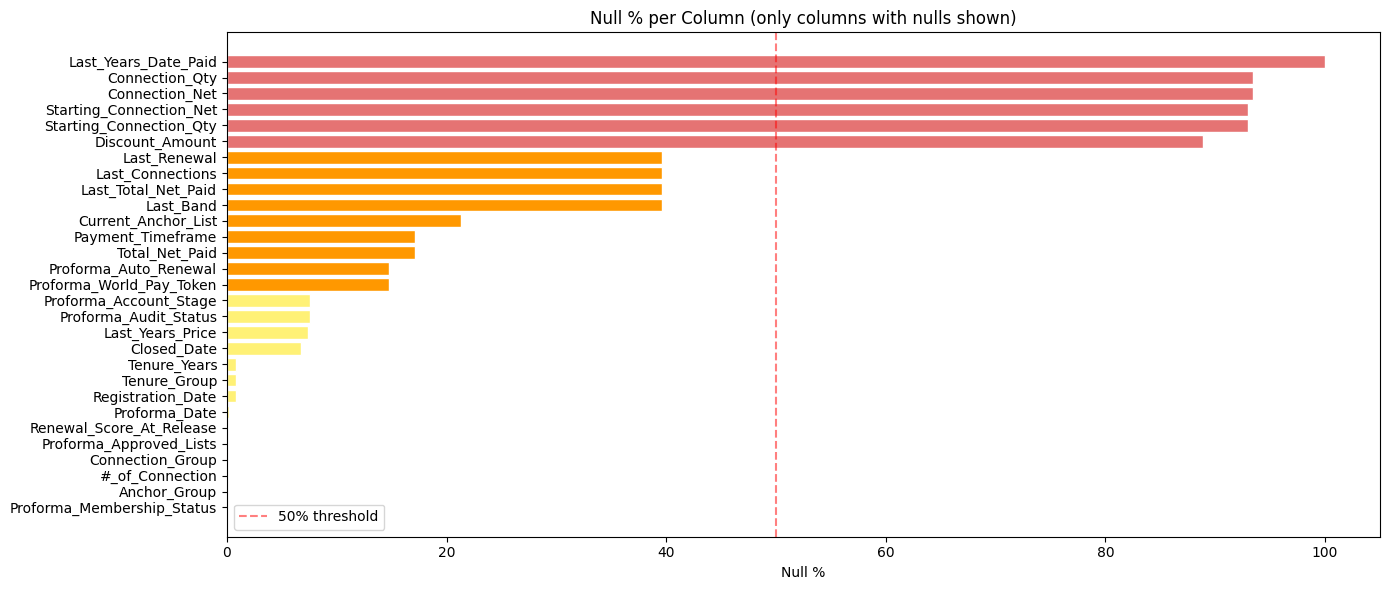


Red = >50% null (consider dropping) | Orange = >10% | Yellow = <10%


In [ ]:
null_df = pd.DataFrame({
    'dtype'     : billings.dtypes,
    'null_count': billings.isnull().sum(),
    'null_pct'  : (billings.isnull().sum() / len(billings) * 100).round(1)
}).sort_values('null_pct', ascending=False)


# Visual: null heatmap
cols_with_nulls = null_df[null_df['null_pct'] > 0].index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
null_vals = null_df.loc[cols_with_nulls, 'null_pct'].values
colors = ['#E57373' if v > 50 else '#FF9800' if v > 10 else '#FFF176' for v in null_vals]
ax.barh(cols_with_nulls[::-1], null_vals[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_xlabel('Null %')
ax.set_title('Null % per Column (only columns with nulls shown)')
ax.legend()
plt.tight_layout()
plt.show()
print('\nRed = >50% null (consider dropping) | Orange = >10% | Yellow = <10%')

## Target Column - Analysis

In [ ]:
outcome_counts = billings['Prospect_Outcome'].value_counts()
print(outcome_counts)

Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64


In [ ]:
outcome_pct = billings['Prospect_Outcome'].value_counts(normalize=True).mul(100).round(1)
print(outcome_pct)

Prospect_Outcome
Won        82.9
Churned    10.4
Open        6.7
Name: proportion, dtype: float64


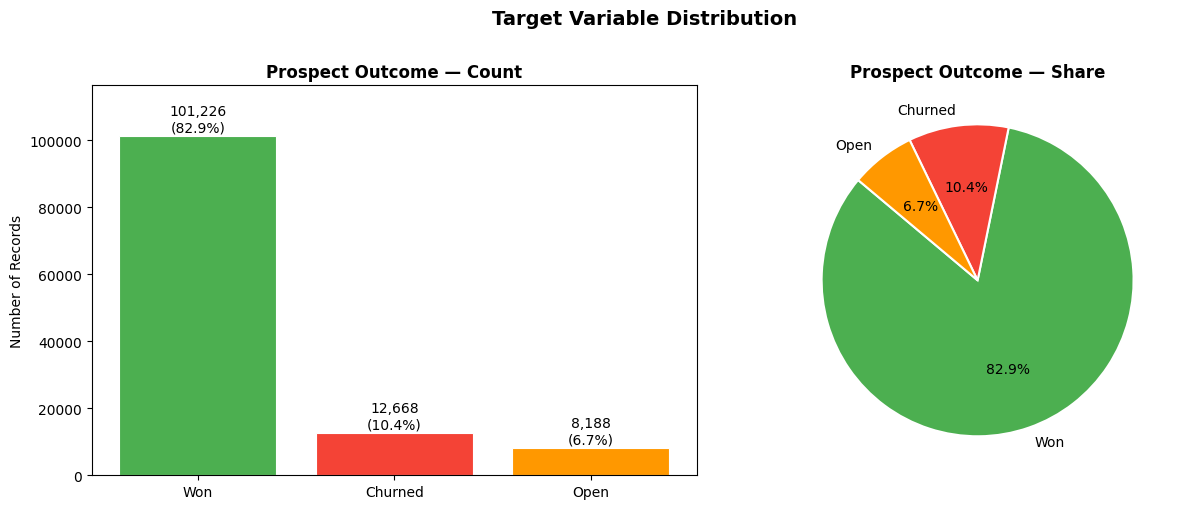

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#4CAF50', '#F44336', '#FF9800']
axes[0].bar(outcome_counts.index, outcome_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, (v, p) in enumerate(zip(outcome_counts.values, outcome_pct.values)):
    axes[0].text(i, v + 500, f'{v:,}\n({p}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Prospect Outcome — Count', fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, outcome_counts.max() * 1.15)

# Pie chart
axes[1].pie(outcome_counts.values, labels=outcome_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Prospect Outcome — Share', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
closed = billings[billings['Prospect_Outcome'].isin(['Won','Churned'])]
won_n     = (closed['Prospect_Outcome']=='Won').sum()
churned_n = (closed['Prospect_Outcome']=='Churned').sum()
ratio     = won_n / churned_n
print(ratio)

7.990685191032523


In [ ]:
print(f'Won    : {won_n:,}  ({won_n/len(closed)*100:.1f}%)')
print(f'Churned: {churned_n:,}  ({churned_n/len(closed)*100:.1f}%)')
print(f'Imbalance ratio: {ratio:.1f}:1  (Won:Churned)')

Won    : 101,226  (88.9%)
Churned: 12,668  (11.1%)
Imbalance ratio: 8.0:1  (Won:Churned)


In [ ]:
print('Implication: This 8:1 imbalance means we must use:')
print('  - class_weight="balanced" in sklearn models, OR')
print('  - SMOTE oversampling on the minority class, OR')
print('  - Evaluation metric: F1-score / ROC-AUC (NOT accuracy)')

Implication: This 8:1 imbalance means we must use:
  - class_weight="balanced" in sklearn models, OR
  - SMOTE oversampling on the minority class, OR
  - Evaluation metric: F1-score / ROC-AUC (NOT accuracy)


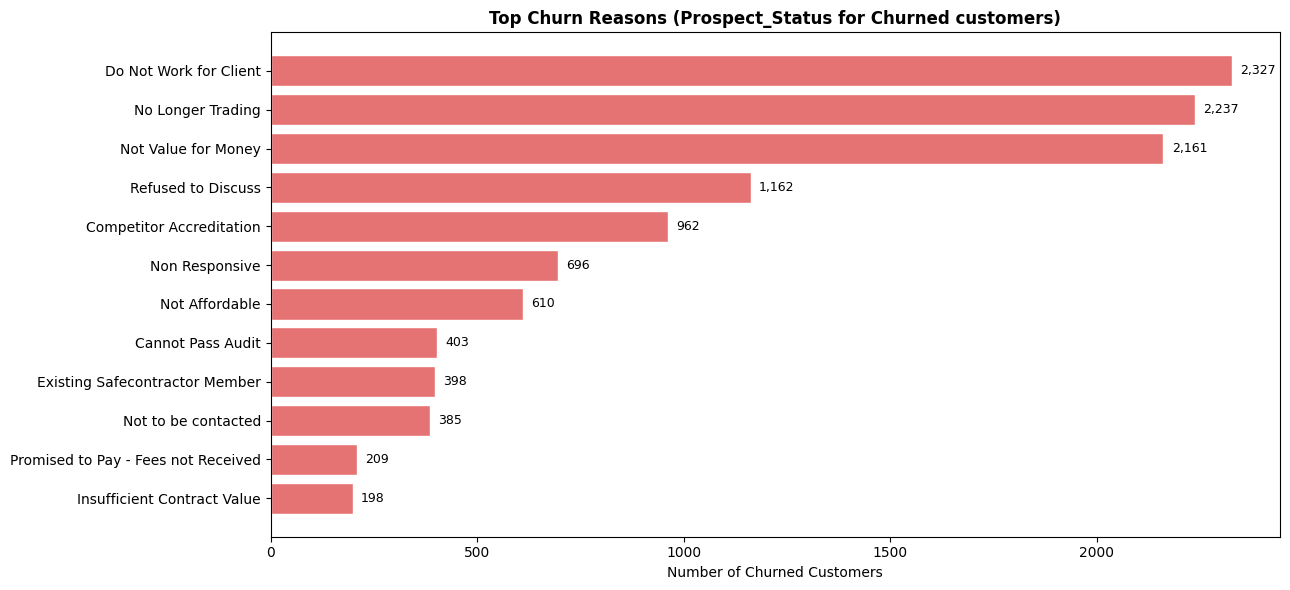

In [ ]:
churn_reasons = (
    billings[billings['Prospect_Outcome'] == 'Churned']['Prospect_Status']
    .value_counts()
    .head(12)
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(churn_reasons.index[::-1], churn_reasons.values[::-1],
               color='#E57373', edgecolor='white')
for bar, val in zip(bars, churn_reasons.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Top Churn Reasons (Prospect_Status for Churned customers)', fontweight='bold')
ax.set_xlabel('Number of Churned Customers')
plt.tight_layout()
plt.show()

## Univariate Analysis

In [ ]:
print('Unique Co_Ref :', billings['Co_Ref'].nunique())
print('Duplicate Co_Ref :', billings.duplicated(subset='Co_Ref').sum())

Unique Co_Ref : 47826
Duplicate Co_Ref : 74256


In [ ]:
print('Explanation: Each Co_Ref (customer) can appear multiple times — once per renewal year.')
print('This is a customer-renewal dataset, not a unique-customer dataset.')

Explanation: Each Co_Ref (customer) can appear multiple times — once per renewal year.
This is a customer-renewal dataset, not a unique-customer dataset.


In [ ]:
print('Renewals per customer:')
print(billings.groupby('Co_Ref').size().describe().round(2))

Renewals per customer:
count    47826.00
mean         2.55
std          1.09
min          1.00
25%          1.00
50%          3.00
75%          3.00
max          5.00
dtype: float64


In [ ]:
sample_ref = billings['Co_Ref'].value_counts().index[0]
print(f'\nSample customer {sample_ref} across years:')
billings[billings['Co_Ref'] == sample_ref][['Co_Ref','Renewal_Year','Band','Amount','Prospect_Outcome']].sort_values('Renewal_Year')


Sample customer PU4860 across years:


,Co_Ref,Renewal_Year,Band,Amount,Prospect_Outcome
92050,PU4860,2023,Band E,1069,Won
63798,PU4860,2024,Band E,1149,Won
19032,PU4860,2025,Band F1,1849,Won
46607,PU4860,2026,Group,3384,Won
78362,PU4860,2027,NaN,0,Churned


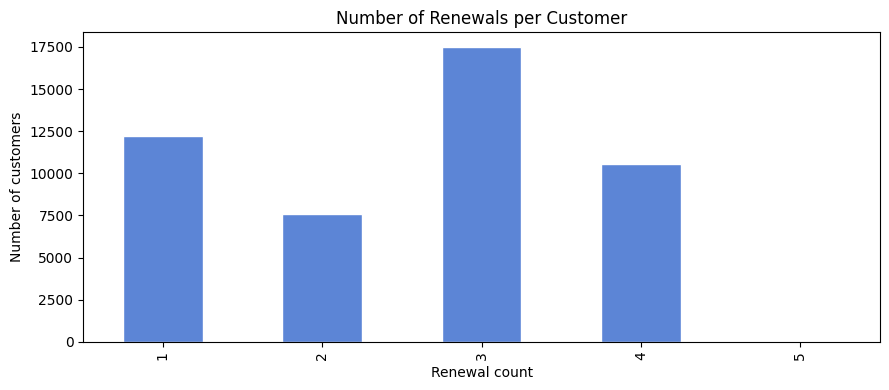

In [ ]:
renewals_per_customer = billings.groupby('Co_Ref').size()

fig, ax = plt.subplots(figsize=(9, 4))
renewals_per_customer.value_counts().sort_index().plot(kind='bar', ax=ax, color='#5C85D6', edgecolor='white')
ax.set_title('Number of Renewals per Customer')
ax.set_xlabel('Renewal count')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

In [ ]:
print('Renewal_Year value counts:')
print(billings['Renewal_Year'].value_counts().sort_index())

Renewal_Year value counts:
Renewal_Year
2023    33925
2024    34601
2025    36601
2026    16950
2027        2
2050        3
Name: count, dtype: int64


In [ ]:
print('Note: 2027 (2 rows) and 2050 (3 rows) are data entry errors — will be dropped.')

Note: 2027 (2 rows) and 2050 (3 rows) are data entry errors — will be dropped.


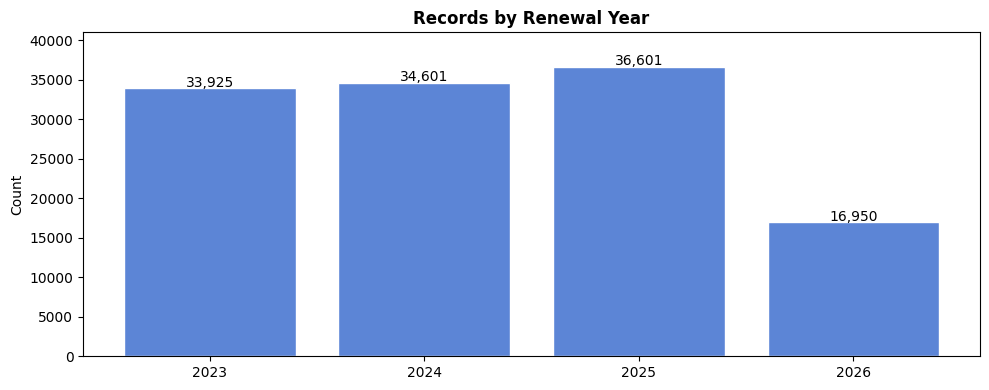

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
year_counts = billings[billings['Renewal_Year'].isin([2023,2024,2025,2026])]['Renewal_Year'].value_counts().sort_index()
ax.bar(year_counts.index.astype(str), year_counts.values, color='#5C85D6', edgecolor='white')
for i, v in enumerate(year_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Records by Renewal Year', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, year_counts.max() * 1.12)
plt.tight_layout()
plt.show()

In [ ]:
print('Columns stored as strings that should be other types:')
print()
print('DATE columns (stored as str, need pd.to_datetime):')
date_cols = ['Prospect_Renewal_Date','Registration_Date','Closed_Date',
             'Proforma_Date','Last_Renewal','DateTime_Out','Renewal_Month']
for col in date_cols:
    print(f'  {col}: sample = {billings[col].dropna().iloc[0]}')

Columns stored as strings that should be other types:

DATE columns (stored as str, need pd.to_datetime):
  Prospect_Renewal_Date: sample = 05-11-2024
  Registration_Date: sample = 05-11-2021
  Closed_Date: sample = 05-11-2024
  Proforma_Date: sample = 06-09-2024
  Last_Renewal: sample = 01-11-2023
  DateTime_Out: sample = 01-11-2024
  Renewal_Month: sample = 01-11-2024


In [ ]:
print('Discount_Amount stored as string % (e.g. "20.00%"):')
print(billings['Discount_Amount'].dropna().value_counts().head(8))

Discount_Amount stored as string % (e.g. "20.00%"):
Discount_Amount
20.00%    6813
30.00%    2152
50.00%    1626
40.00%    1383
10.00%     886
15.00%     474
35.00%     122
25.00%      62
Name: count, dtype: int64


In [ ]:
print('Mixed type columns (True/False stored as object):')
for col in ['Proforma_Auto_Renewal','Proforma_World_Pay_Token']:
    print(f'  {col}:', billings[col].dropna().value_counts().to_dict())

Mixed type columns (True/False stored as object):
  Proforma_Auto_Renewal: {True: 102435, False: 1595}
  Proforma_World_Pay_Token: {False: 61563, True: 42467}


In [ ]:
print('Amount stats:')
print(billings['Amount'].describe().round(2))
print(f'\nZero  Amount rows: {(billings["Amount"]==0).sum()}')
print(f'Max Amount: {billings["Amount"].max():,}')
print()
print('Zero-amount row breakdown:')
print(billings[billings['Amount']==0]['Prospect_Status'].value_counts())

Amount stats:
count    122082.00
mean       1107.75
std         689.14
min           0.00
25%         699.00
50%         934.00
75%        1274.00
max       19927.00
Name: Amount, dtype: float64

Zero  Amount rows: 129
Max Amount: 19,927

Zero-amount row breakdown:
Prospect_Status
Duplicate Entry                             60
Renewed                                     38
Application and Money In                    15
Do Not Work for Client                       3
unknown                                      2
Renewal Proforma Sent                        1
Not Value for Money                          1
Not Affordable                               1
Existing Safecontractor Member               1
No Longer Trading                            1
Invoiced                                     1
Paid                                         1
Insufficient Contract Value                  1
Promised to Pay - Fees not Received          1
Decline 3rd party accreditation requests     1
Poor Customer

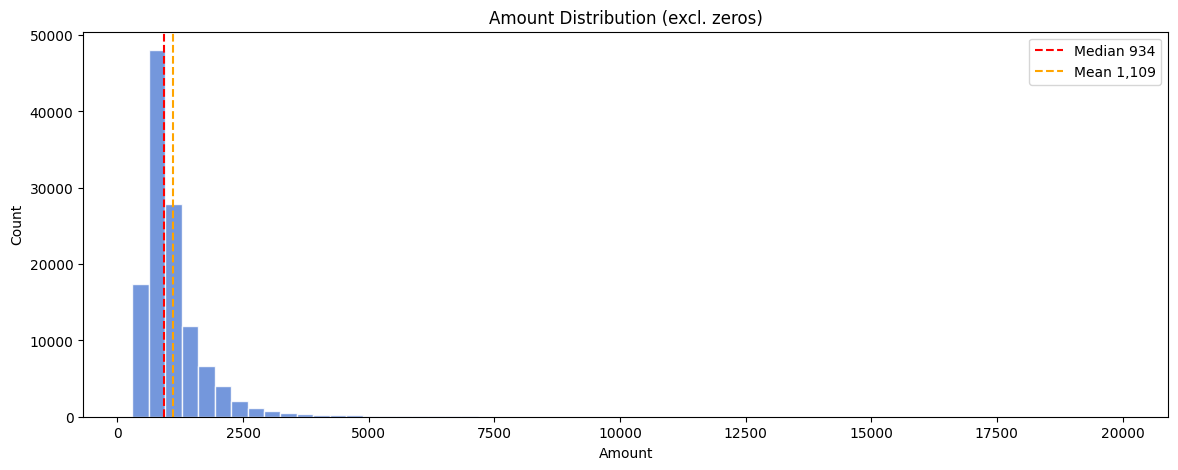

In [ ]:
fig,axes = plt.subplots(1, figsize=(14, 5))
amt = billings[billings['Amount'] > 0]['Amount']
axes.hist(amt, bins=60, color='#5C85D6', edgecolor='white', alpha=0.85)
axes.axvline(amt.median(), color='red',    linestyle='--', label=f'Median {amt.median():,.0f}')
axes.axvline(amt.mean(),   color='orange', linestyle='--', label=f'Mean {amt.mean():,.0f}')
axes.set_title('Amount Distribution (excl. zeros)')
axes.set_xlabel('Amount')
axes.set_ylabel('Count')
axes.legend()

plt.show()

In [ ]:
print('Tenure_Years stats:')
print(billings['Tenure_Years'].describe().round(2))

Tenure_Years stats:
count    121064.00
mean          6.87
std           5.43
min           0.00
25%           2.00
50%           5.00
75%          10.00
max          30.00
Name: Tenure_Years, dtype: float64


In [ ]:
print('Value counts (top 20):')
print(billings['Tenure_Years'].value_counts().sort_index().head(20))

Value counts (top 20):
Tenure_Years
0.0       179
1.0     19364
2.0     14175
3.0     11019
4.0      9083
5.0      7481
6.0      6830
7.0      6627
8.0      6257
9.0      5780
10.0     5203
11.0     4332
12.0     3693
13.0     3399
14.0     3251
15.0     3162
16.0     2804
17.0     2051
18.0     1542
19.0     1375
Name: count, dtype: int64


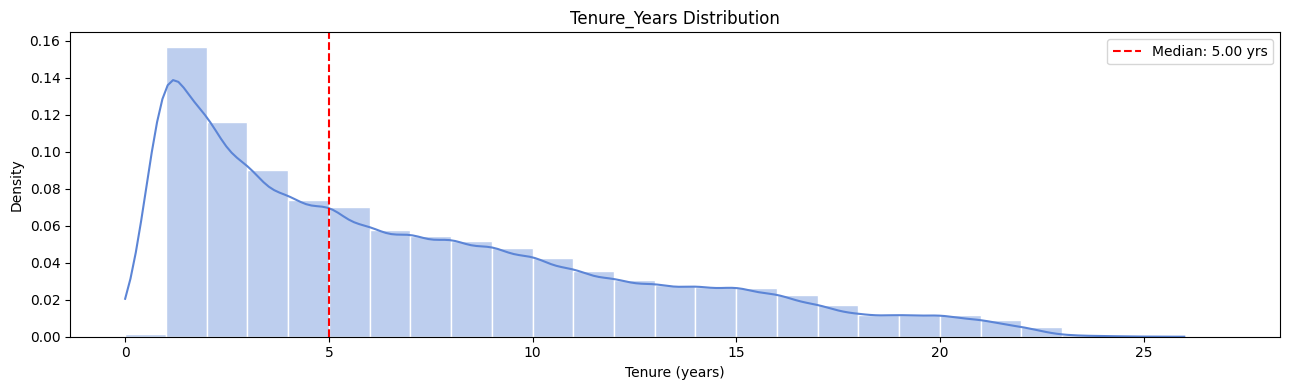

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

# Drop NA → keep as Series
ten = billings['Tenure_Years'].dropna()

# Histogram + KDE
sns.histplot(
    ten,
    bins=range(0, int(ten.max()) + 2),
    kde=True,              # bell curve
    stat="density",        # for proper KDE scaling
    color='#5C85D6',
    alpha=0.4,
    edgecolor='white',
    ax=ax
)

# Median line
median_val = ten.median()
ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f} yrs')

# Labels
ax.set_title('Tenure_Years Distribution')
ax.set_xlabel('Tenure (years)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

Score column stats:
       Total_Renewal_Score_New  Auto_Renewal_Score  Status_Scores  \
count                122082.00           122082.00      122082.00   
mean                     41.98                8.48           7.19   
std                       4.29                0.50           3.26   
min                      30.50                8.00           0.00   
25%                      41.50                8.00           7.00   
50%                      43.50                8.00           9.00   
75%                      45.00                9.00           9.00   
max                      46.50                9.00           9.00   

       Anchoring_Score  Tenure_Scores  Sustainability_Score  
count        122082.00      122082.00             122082.00  
mean              8.70           9.00                  8.62  
std               0.74           0.63                  0.69  
min               7.50           7.00                  8.00  
25%               8.50           8.50           

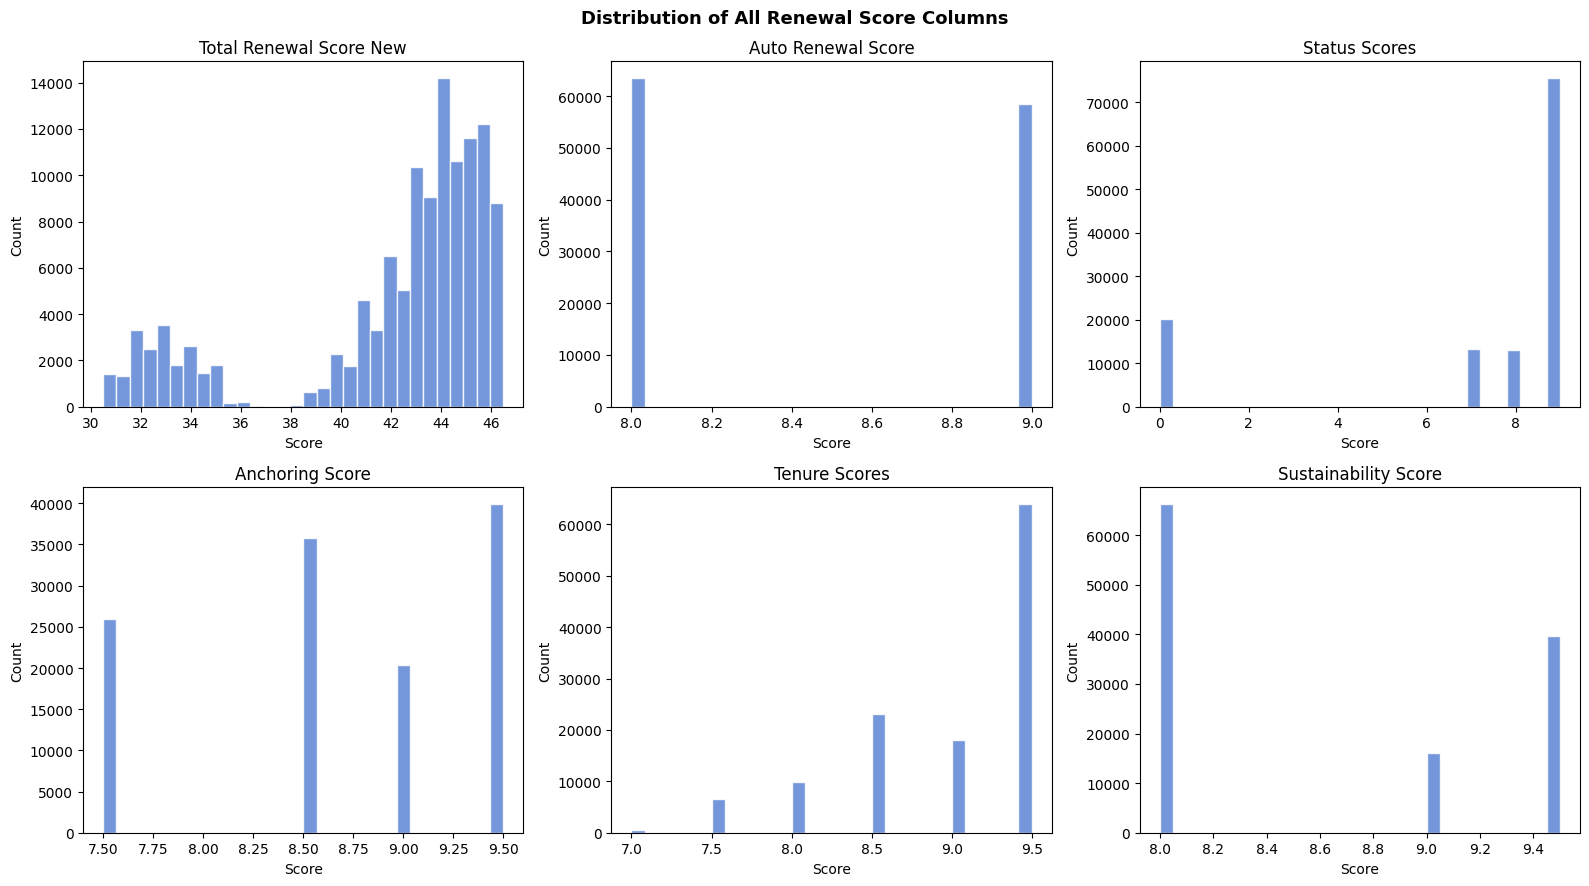

In [ ]:
score_cols = ['Total_Renewal_Score_New','Auto_Renewal_Score','Status_Scores',
              'Anchoring_Score','Tenure_Scores','Sustainability_Score']

print('Score column stats:')
print(billings[score_cols].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), score_cols):
    ax.hist(billings[col].dropna(), bins=30, color='#5C85D6', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
plt.suptitle('Distribution of All Renewal Score Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
yearly = (
    closed[closed['Renewal_Year'].isin([2023,2024,2025,2026])]
    .groupby('Renewal_Year')['Prospect_Outcome']
    .apply(lambda x: (x=='Churned').mean() * 100)
    .round(2)
)

print('Churn rate by year:')
print(yearly)

Churn rate by year:
Renewal_Year
2023    13.13
2024    10.56
2025    10.25
2026     9.21
Name: Prospect_Outcome, dtype: float64


In [ ]:
yearly_counts = (
    closed[closed['Renewal_Year'].isin([2023,2024,2025,2026])]
    .groupby(['Renewal_Year','Prospect_Outcome']).size().unstack(fill_value=0)
)

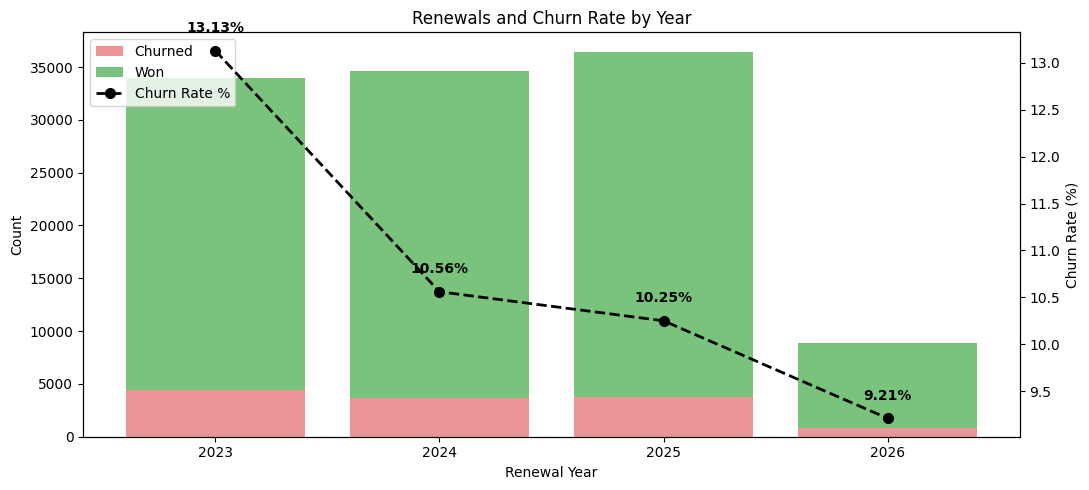

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
years = yearly_counts.index.astype(str)
ax1.bar(years, yearly_counts.get('Churned',0), color='#E57373', alpha=0.75, label='Churned')
ax1.bar(years, yearly_counts.get('Won',0),
        bottom=yearly_counts.get('Churned',0), color='#4CAF50', alpha=0.75, label='Won')
ax2.plot(years, yearly.values, 'ko--', linewidth=2, markersize=7, label='Churn Rate %')
for x, y in zip(years, yearly.values):
    ax2.text(x, y + 0.2, f'{y}%', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Renewals and Churn Rate by Year')
ax1.set_xlabel('Renewal Year')
ax1.set_ylabel('Count')
ax2.set_ylabel('Churn Rate (%)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

Band distribution:
Band
Band A      3764
Band B     32731
Band C1    24922
Band C2    15765
Band D     18965
Band E      9652
Band F      2193
Band F1     5905
Band F2     3184
Band G      2391
Band H       823
Band I       380
Band J       397
Group        986
Name: count, dtype: int64


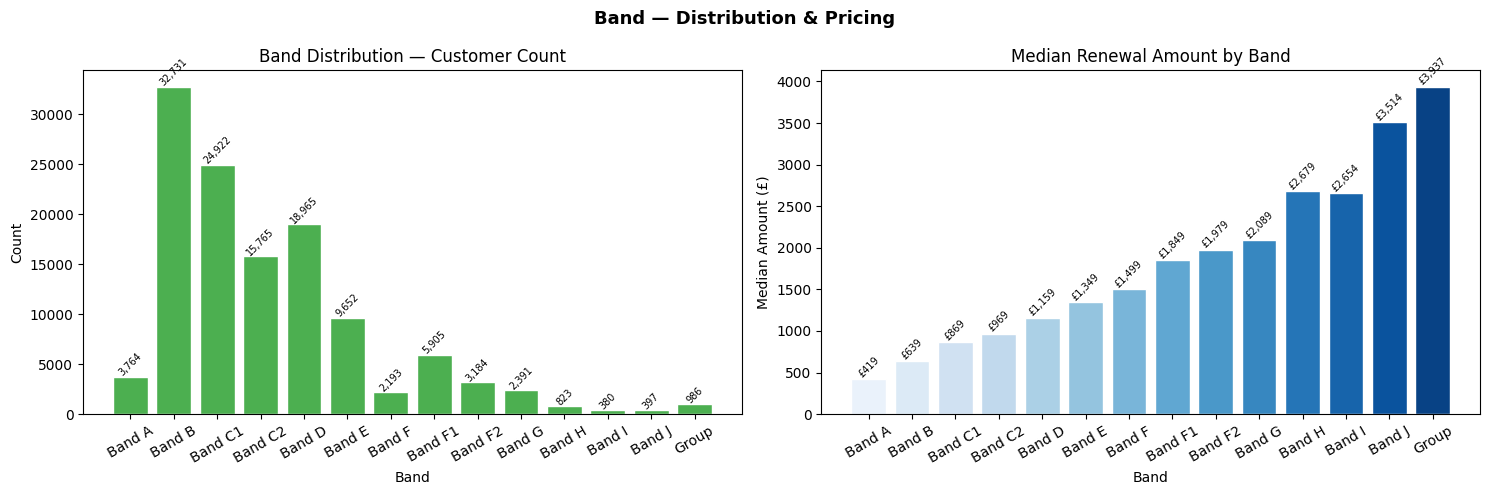

In [ ]:
import seaborn as sns

band_order = ['Band A','Band B','Band C1','Band C2','Band D','Band E',
              'Band F','Band F1','Band F2','Band G','Band H','Band I','Band J','Group']
band_vc = billings['Band'].value_counts().reindex(band_order).dropna()
print('Band distribution:')
print(band_vc)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(band_vc.index, band_vc.values, color='#4CAF50', edgecolor='white')
for i, v in enumerate(band_vc.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=7, rotation=45)
axes[0].set_title('Band Distribution — Customer Count')
axes[0].set_xlabel('Band')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

band_med_amt = billings.groupby('Band')['Amount'].median().reindex(band_order).dropna()
axes[1].bar(band_med_amt.index, band_med_amt.values,
            color=sns.color_palette('Blues', len(band_med_amt)), edgecolor='white')
for i, v in enumerate(band_med_amt.values):
    axes[1].text(i, v + 20, f'£{v:,.0f}', ha='center', fontsize=7, rotation=45)
axes[1].set_title('Median Renewal Amount by Band')
axes[1].set_xlabel('Band')
axes[1].set_ylabel('Median Amount (£)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Band — Distribution & Pricing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

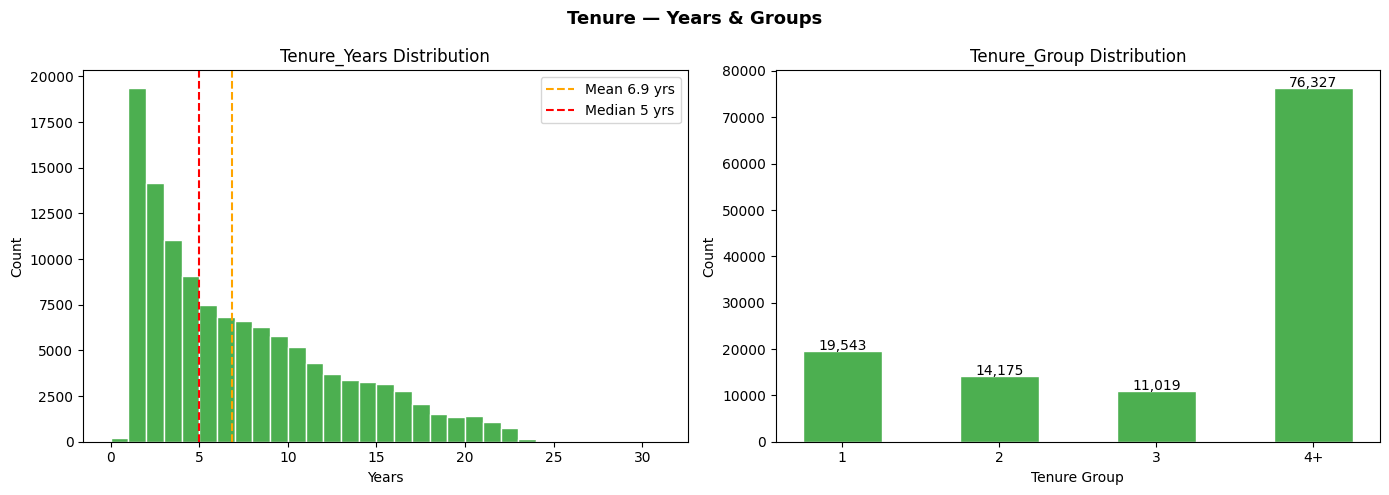

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ten = billings['Tenure_Years'].dropna()
axes[0].hist(ten, bins=range(0, int(ten.max())+2), color='#4CAF50', edgecolor='white')
axes[0].axvline(ten.mean(),   color='orange', linestyle='--', label=f'Mean {ten.mean():.1f} yrs')
axes[0].axvline(ten.median(), color='red',    linestyle='--', label=f'Median {ten.median():.0f} yrs')
axes[0].set_title('Tenure_Years Distribution')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Count')
axes[0].legend()

tg_order = ['1','2','3','4+']
tg_vc = billings['Tenure_Group'].value_counts().reindex(tg_order)
axes[1].bar(tg_vc.index, tg_vc.values, color='#4CAF50', edgecolor='white', width=0.5)
for i, v in enumerate(tg_vc.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
axes[1].set_title('Tenure_Group Distribution')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Count')

plt.suptitle('Tenure — Years & Groups', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

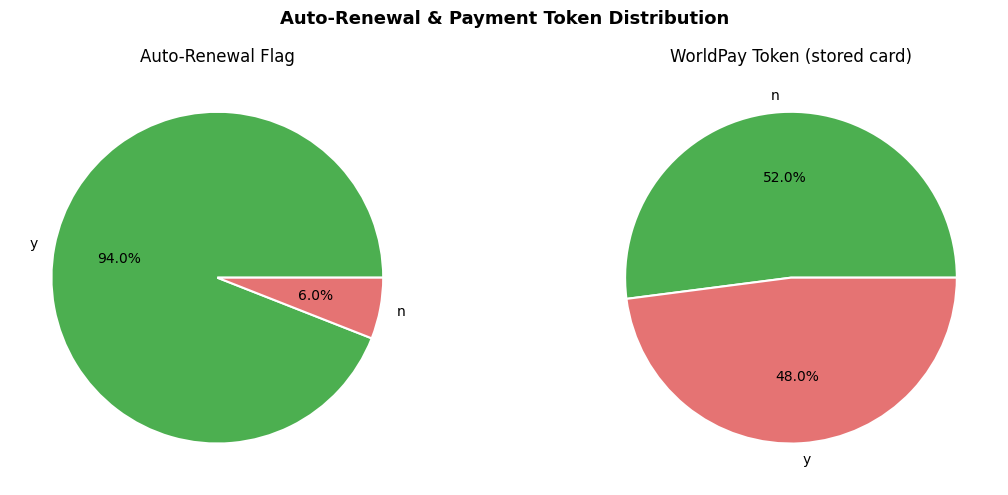

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ['Current_Auto_Renewal_Flag','Current_World_Pay_Token'],
    ['Auto-Renewal Flag','WorldPay Token (stored card)']
):
    vc = billings[col].value_counts()
    ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
           colors=['#4CAF50', '#E57373'],
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(title)

plt.suptitle('Auto-Renewal & Payment Token Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Payment_Method
CARD         71101
BACS         33191
UNKNOWN      16020
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64


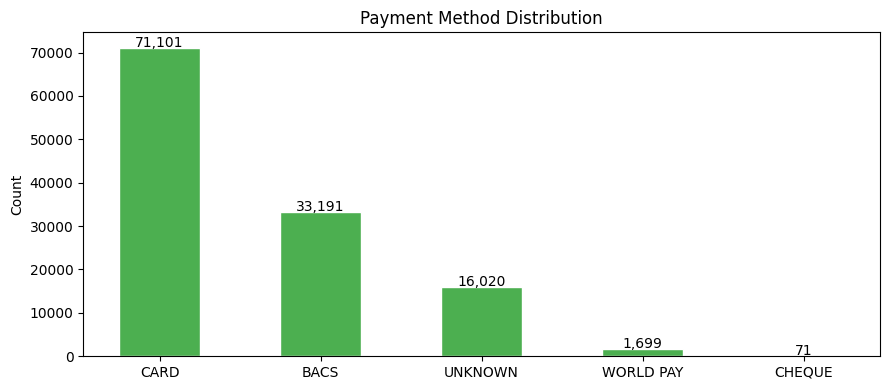

Note: UNKNOWN payment method is a flag — no confirmed payment method = higher churn risk.


In [ ]:
pm_vc = billings['Payment_Method'].value_counts()
print(pm_vc)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(pm_vc.index, pm_vc.values, color='#4CAF50', edgecolor='white', width=0.5)
for i, v in enumerate(pm_vc.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Payment Method Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print('Note: UNKNOWN payment method is a flag — no confirmed payment method = higher churn risk.')

Connection_Group:
Connection_Group
Independent    25088
1              38137
2              19408
3              10463
4 to 9         20607
10+             8253
Name: count, dtype: int64


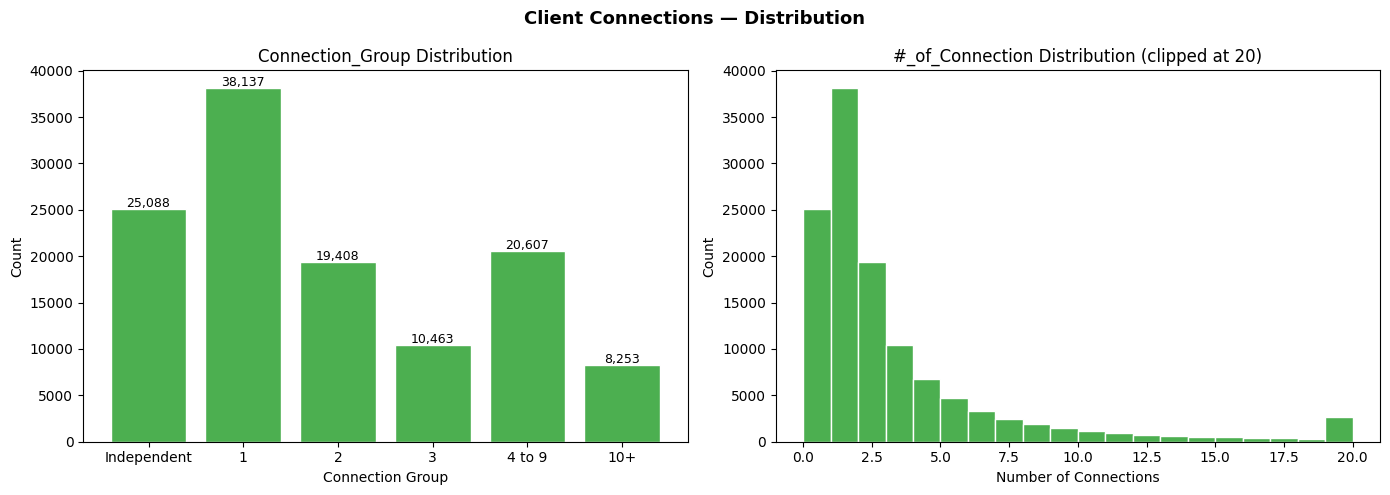

In [ ]:
conn_order = ['Independent','1','2','3','4 to 9','10+']
cg_vc = billings['Connection_Group'].value_counts().reindex(conn_order).dropna()
print('Connection_Group:')
print(cg_vc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cg_vc.index, cg_vc.values, color='#4CAF50', edgecolor='white')
for i, v in enumerate(cg_vc.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
axes[0].set_title('Connection_Group Distribution')
axes[0].set_xlabel('Connection Group')
axes[0].set_ylabel('Count')

conn = billings['#_of_Connection'].dropna()
axes[1].hist(conn.clip(upper=20), bins=20, color='#4CAF50', edgecolor='white')
axes[1].set_title('#_of_Connection Distribution (clipped at 20)')
axes[1].set_xlabel('Number of Connections')
axes[1].set_ylabel('Count')

plt.suptitle('Client Connections — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

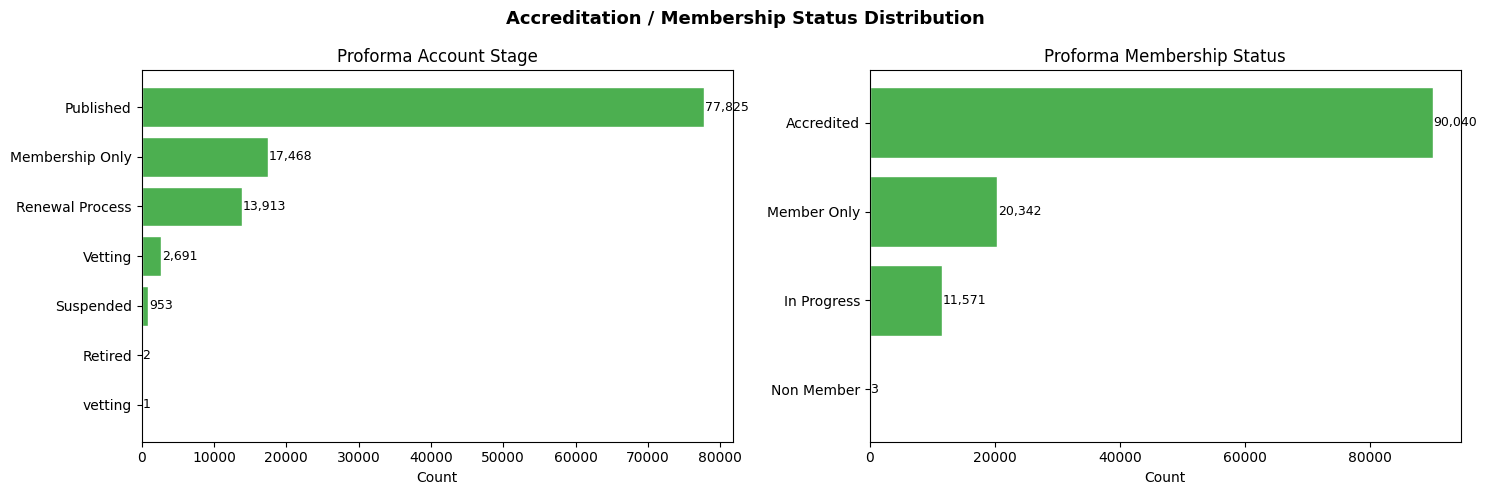

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes, ['Proforma_Account_Stage','Proforma_Membership_Status']):
    vc = billings[col].value_counts().head(10)
    ax.barh(vc.index[::-1], vc.values[::-1], color='#4CAF50', edgecolor='white')
    for bar, v in zip(ax.patches, vc.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9)
    ax.set_title(col.replace('_',' '))
    ax.set_xlabel('Count')

plt.suptitle('Accreditation / Membership Status Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Price change % stats:
count    112799.00
mean         38.81
std         403.69
min         -83.73
25%           0.00
50%           0.00
75%           0.00
max       36390.00
Name: price_delta_pct, dtype: float64

% with price increase : 19.1%
% with no change      : 68.2%
% with price decrease : 12.6%


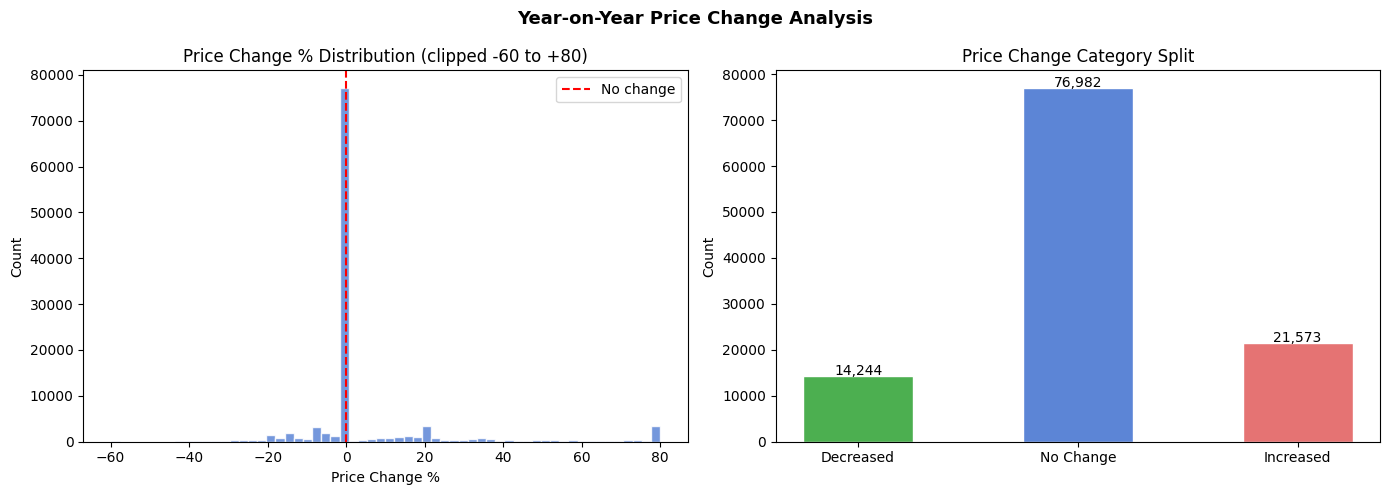

In [ ]:
price_df = billings[(billings['Amount'] > 0) & (billings['Last_Years_Price'] > 0)].copy()
price_df['price_delta_pct'] = (
    (price_df['Amount'] - price_df['Last_Years_Price']) / price_df['Last_Years_Price'] * 100
).round(2)

print('Price change % stats:')
print(price_df['price_delta_pct'].describe().round(2))
print(f'\n% with price increase : {(price_df["price_delta_pct"] > 0).mean()*100:.1f}%')
print(f'% with no change      : {(price_df["price_delta_pct"] == 0).mean()*100:.1f}%')
print(f'% with price decrease : {(price_df["price_delta_pct"] < 0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clipped = price_df['price_delta_pct'].clip(-60, 80)
axes[0].hist(clipped, bins=60, color='#5C85D6', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', label='No change')
axes[0].set_title('Price Change % Distribution (clipped -60 to +80)')
axes[0].set_xlabel('Price Change %')
axes[0].set_ylabel('Count')
axes[0].legend()

cats = ['Decreased','No Change','Increased']
cat_counts = [
    (price_df['price_delta_pct'] < 0).sum(),
    (price_df['price_delta_pct'] == 0).sum(),
    (price_df['price_delta_pct'] > 0).sum()
]
axes[1].bar(cats, cat_counts, color=['#4CAF50', '#5C85D6', '#E57373'], edgecolor='white', width=0.5)
for i, v in enumerate(cat_counts):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
axes[1].set_title('Price Change Category Split')
axes[1].set_ylabel('Count')

plt.suptitle('Year-on-Year Price Change Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Analysis - Each Columns vs Churn

In [ ]:
# Working subset: closed records only
sub = billings[billings['Prospect_Outcome'].isin(['Won','Churned'])].copy()
sub['churn'] = (sub['Prospect_Outcome']=='Churned').astype(int)
overall_churn = sub['churn'].mean() * 100
print(f'Working subset: {len(sub):,} rows | Overall churn: {overall_churn:.1f}%')

Working subset: 113,894 rows | Overall churn: 11.1%


              churn_rate      n   pct
Tenure_Group                         
1               0.218074  18026  21.8
2               0.160024  13198  16.0
3               0.137740  10273  13.8
4+              0.071253  71422   7.1


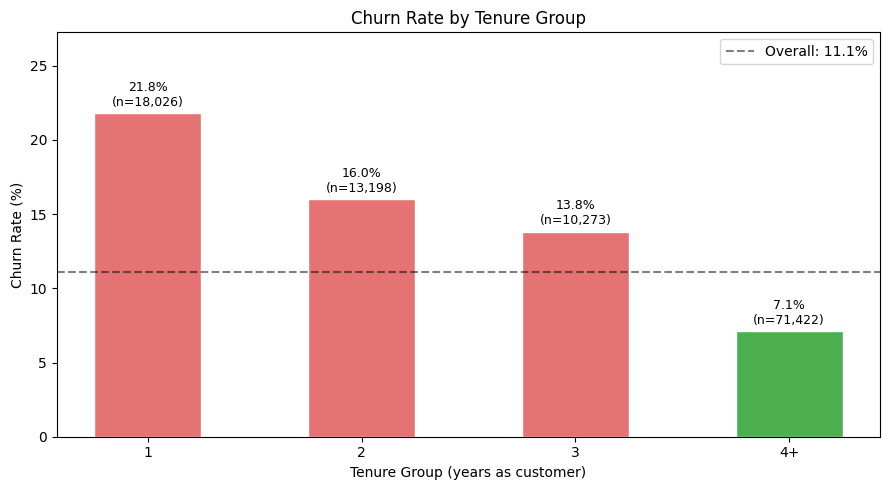

Insight: Year-1 customers churn at 2-3x the rate of long-tenure customers.


In [ ]:
tg_order = ['1','2','3','4+']
tg_churn = (
    sub.groupby('Tenure_Group')['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
    .reindex(tg_order)
)
tg_churn['pct'] = (tg_churn['churn_rate'] * 100).round(1)
print(tg_churn)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E57373' if v > overall_churn else '#4CAF50' for v in tg_churn['pct']]
bars = ax.bar(tg_churn.index, tg_churn['pct'], color=colors, edgecolor='white', width=0.5)
for bar, val, n in zip(bars, tg_churn['pct'], tg_churn['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)
ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
ax.set_title('Churn Rate by Tenure Group')
ax.set_xlabel('Tenure Group (years as customer)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, tg_churn['pct'].max() * 1.25)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: Year-1 customers churn at 2-3x the rate of long-tenure customers.')

                     churn_rate       n   pct
No Auto-Renewal (n)    0.288497    7033  28.8
Auto-Renewal (y)       0.099559  106861  10.0


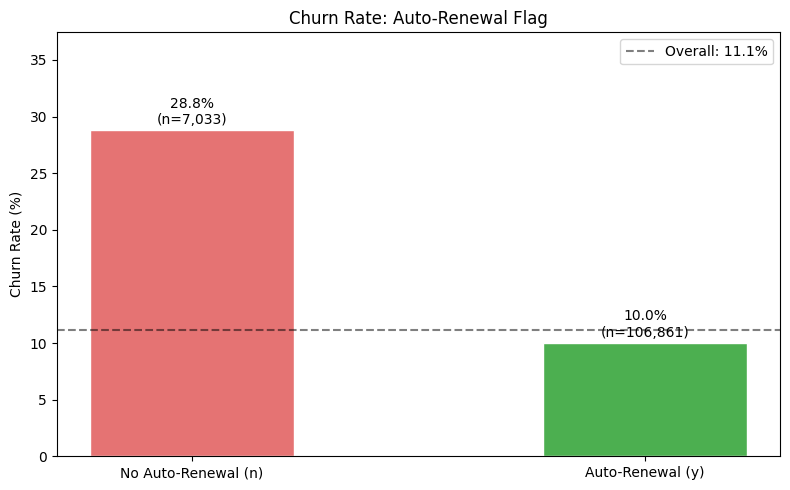

Insight: Customers WITHOUT auto-renewal churn at ~3x the rate of those with it.


In [ ]:
ar_churn = (
    sub.groupby('Current_Auto_Renewal_Flag')['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
)
ar_churn['pct'] = (ar_churn['churn_rate']*100).round(1)
ar_churn.index = ['No Auto-Renewal (n)','Auto-Renewal (y)']
print(ar_churn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ar_churn.index, ar_churn['pct'], color=['#E57373', '#4CAF50'], edgecolor='white', width=0.45)
for i, (val, n) in enumerate(zip(ar_churn['pct'], ar_churn['n'])):
    ax.text(i, val+0.3, f'{val}%\n(n={n:,})', ha='center', va='bottom', fontsize=10)
ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
ax.set_title('Churn Rate: Auto-Renewal Flag')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, ar_churn['pct'].max() * 1.3)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: Customers WITHOUT auto-renewal churn at ~3x the rate of those with it.')

         churn_rate      n   pct
Band                            
Band A     0.220551   3523  22.1
Band B     0.173587  30492  17.4
Band C1    0.109807  23168  11.0
Band C2    0.082649  14737   8.3
Band D     0.070937  17720   7.1
Band E     0.064326   9001   6.4
Band F     0.063383   2193   6.3
Band F1    0.061844   5433   6.2
Band F2    0.067030   2939   6.7
Band G     0.066459   2242   6.6
Band H     0.067620    769   6.8
Band I     0.082192    365   8.2
Band J     0.066298    362   6.6
Group      0.058065    930   5.8


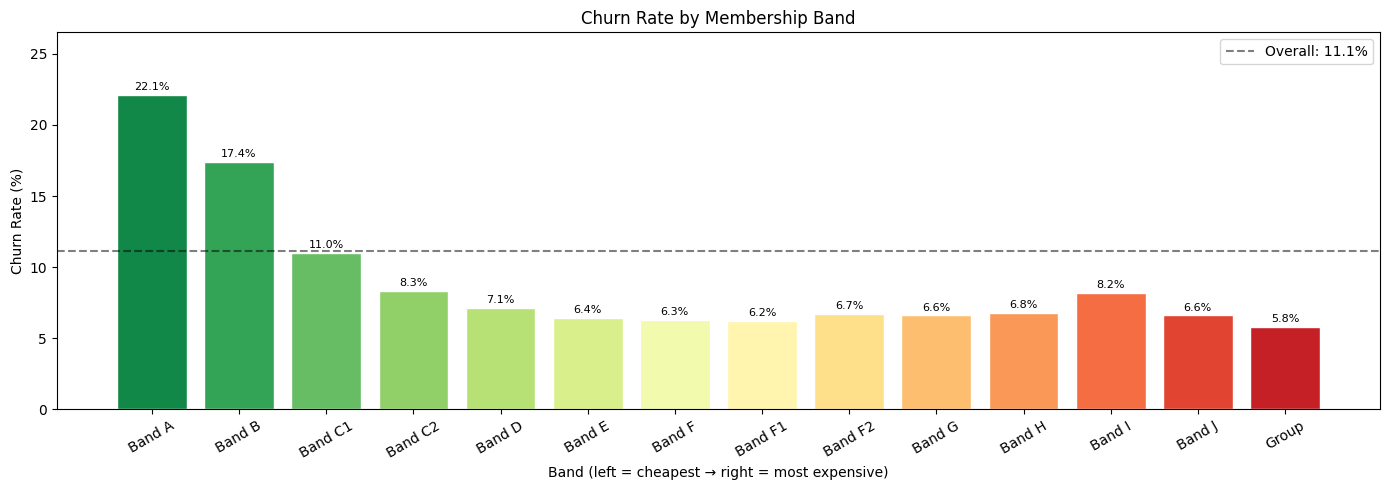

Insight: Lower bands (smaller businesses) churn more — they are more price-sensitive.


In [ ]:
band_churn = (
    sub.groupby('Band')['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
    .reindex(band_order)
    .dropna(subset=['churn_rate'])
)
band_churn['pct'] = (band_churn['churn_rate']*100).round(1)
print(band_churn)

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('RdYlGn_r', len(band_churn))
bars = ax.bar(band_churn.index, band_churn['pct'], color=palette, edgecolor='white')
for bar, val in zip(bars, band_churn['pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val}%', ha='center', va='bottom', fontsize=8)
ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
ax.set_title('Churn Rate by Membership Band')
ax.set_xlabel('Band (left = cheapest → right = most expensive)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, band_churn['pct'].max()*1.2)
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: Lower bands (smaller businesses) churn more — they are more price-sensitive.')

                churn_rate      n    pct
Payment_Method                          
UNKNOWN           1.000000   7832  100.0
CARD              0.068016  71101    6.8
BACS              0.000000  33191    0.0
CHEQUE            0.000000     71    0.0
WORLD PAY         0.000000   1699    0.0


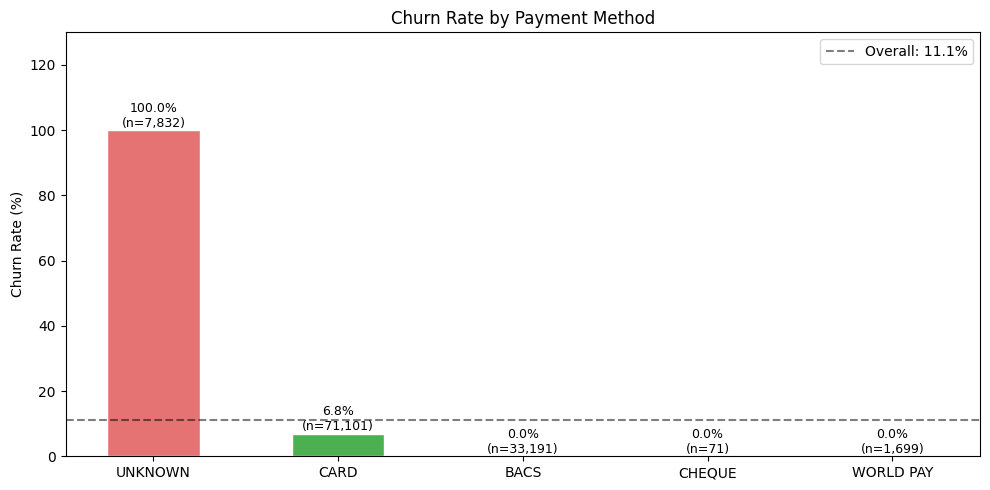

Insight: UNKNOWN payment method = highest churn — these customers have no confirmed payment method.


In [ ]:
pm_churn = (
    sub.groupby('Payment_Method')['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
    .sort_values('churn_rate', ascending=False)
)
pm_churn['pct'] = (pm_churn['churn_rate']*100).round(1)
print(pm_churn)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E57373' if v > overall_churn else '#4CAF50' for v in pm_churn['pct']]
bars = ax.bar(pm_churn.index, pm_churn['pct'], color=colors, edgecolor='white', width=0.5)
for bar, val, n in zip(bars, pm_churn['pct'], pm_churn['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)
ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
ax.set_title('Churn Rate by Payment Method')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, pm_churn['pct'].max()*1.3)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: UNKNOWN payment method = highest churn — these customers have no confirmed payment method.')

                  churn_rate      n   pct
Connection_Group                         
Independent         0.198720  23118  19.9
1                   0.140087  35435  14.0
2                   0.084274  18167   8.4
3                   0.058901   9830   5.9
4 to 9              0.038847  19435   3.9
10+                 0.022345   7787   2.2


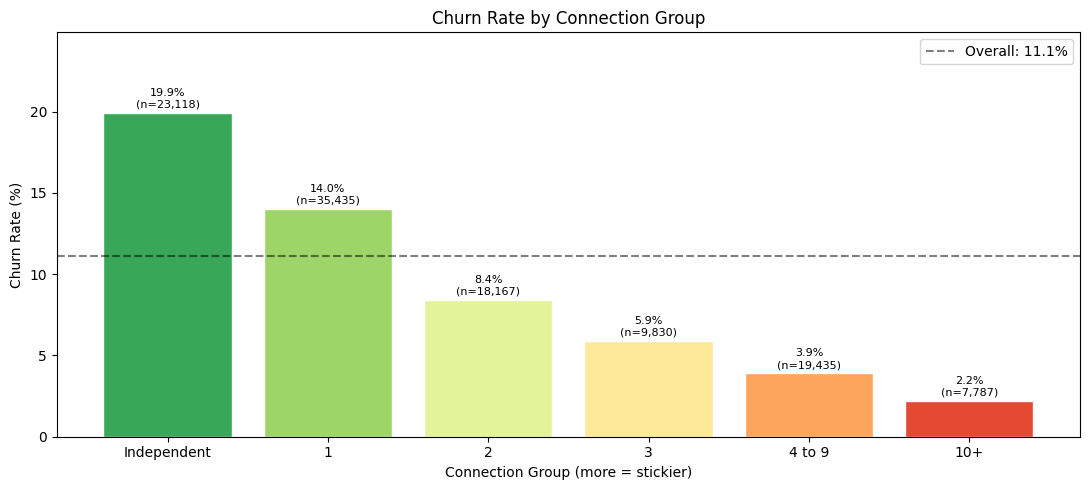

Insight: Independent customers (0 client links) churn most — they have least reason to stay.


In [ ]:
conn_order = ['Independent','1','2','3','4 to 9','10+']
cg_churn = (
    sub.groupby('Connection_Group')['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
    .reindex(conn_order)
    .dropna(subset=['churn_rate'])
)
cg_churn['pct'] = (cg_churn['churn_rate']*100).round(1)
print(cg_churn)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('RdYlGn_r', len(cg_churn))
bars = ax.bar(cg_churn.index, cg_churn['pct'], color=colors, edgecolor='white')
for bar, val, n in zip(bars, cg_churn['pct'], cg_churn['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val}%\n(n={n:,})', ha='center', va='bottom', fontsize=8)
ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
ax.set_title('Churn Rate by Connection Group')
ax.set_xlabel('Connection Group (more = stickier)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, cg_churn['pct'].max()*1.25)
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: Independent customers (0 client links) churn most — they have least reason to stay.')

              churn_rate      n   pct
price_bucket                         
Decreased       0.009483  14341   0.9
No Change       0.082384  69528   8.2
Up 1-10%        0.041052   2168   4.1
Up 10-20%       0.105967   5162  10.6
Up 20%+         0.267119  12968  26.7


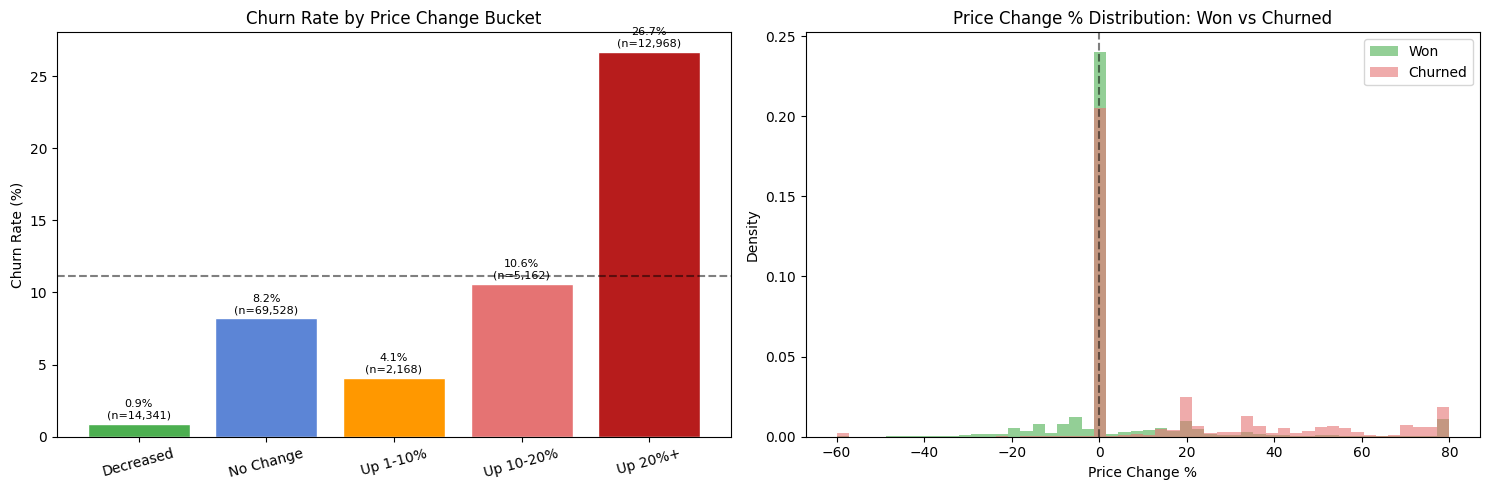

In [ ]:
price_sub = sub[sub['Last_Years_Price'] > 0].copy()
price_sub['price_delta_pct'] = (
    (price_sub['Amount'] - price_sub['Last_Years_Price']) / price_sub['Last_Years_Price'] * 100
).round(2)
price_sub['price_bucket'] = pd.cut(
    price_sub['price_delta_pct'],
    bins=[-999, -0.01, 0.01, 10, 20, 999],
    labels=['Decreased','No Change','Up 1-10%','Up 10-20%','Up 20%+']
)
pb_churn = (
    price_sub.groupby('price_bucket', observed=True)['churn']
    .agg(['mean','count'])
    .rename(columns={'mean':'churn_rate','count':'n'})
)
pb_churn['pct'] = (pb_churn['churn_rate']*100).round(1)
print(pb_churn)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#4CAF50', '#5C85D6', '#FF9800', '#E57373', '#B71C1C']
axes[0].bar(pb_churn.index, pb_churn['pct'], color=colors[:len(pb_churn)], edgecolor='white')
for i, (val, n) in enumerate(zip(pb_churn['pct'], pb_churn['n'])):
    axes[0].text(i, val+0.2, f'{val}%\n(n={n:,})', ha='center', va='bottom', fontsize=8)
axes[0].axhline(overall_churn, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Churn Rate by Price Change Bucket')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

won_d    = price_sub[price_sub['churn']==0]['price_delta_pct'].clip(-60, 80)
churned_d= price_sub[price_sub['churn']==1]['price_delta_pct'].clip(-60, 80)
axes[1].hist(won_d,     bins=50, alpha=0.6, color='#4CAF50',   label='Won',     density=True)
axes[1].hist(churned_d, bins=50, alpha=0.6, color='#E57373', label='Churned', density=True)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Price Change % Distribution: Won vs Churned')
axes[1].set_xlabel('Price Change %')
axes[1].set_ylabel('Density')
axes[1].legend()
plt.tight_layout()
plt.show()

Amount stats — Won:
count    101226.00
mean       1109.43
std         666.78
min           0.00
25%         704.00
50%         949.00
75%        1279.00
max       17877.00
Name: Amount, dtype: float64

Amount stats — Churned:
count    12668.00
mean       899.72
std        485.69
min          0.00
25%        639.00
50%        749.00
75%        999.00
max       9346.00
Name: Amount, dtype: float64


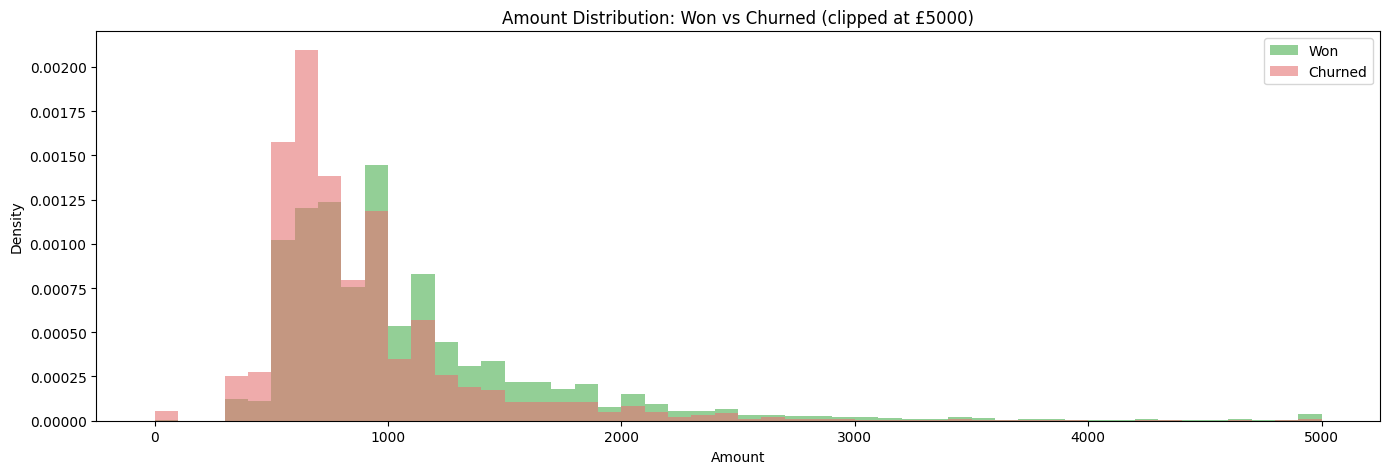

Insight: Churned customers tend to have lower renewal amounts (lower bands = smaller businesses).


In [ ]:
won_amt    = sub[sub['churn']==0]['Amount']
churned_amt= sub[sub['churn']==1]['Amount']

print('Amount stats — Won:')
print(won_amt.describe().round(2))
print('\nAmount stats — Churned:')
print(churned_amt.describe().round(2))

fig, axes = plt.subplots(1, figsize=(14, 5))
axes.hist(won_amt.clip(upper=5000),     bins=50, alpha=0.6, color='#4CAF50',   label='Won',     density=True)
axes.hist(churned_amt.clip(upper=5000), bins=50, alpha=0.6, color='#E57373', label='Churned', density=True)
axes.set_title('Amount Distribution: Won vs Churned (clipped at £5000)')
axes.set_xlabel('Amount')
axes.set_ylabel('Density')
axes.legend()


plt.suptitle('')
plt.tight_layout()
plt.show()
print('Insight: Churned customers tend to have lower renewal amounts (lower bands = smaller businesses).')

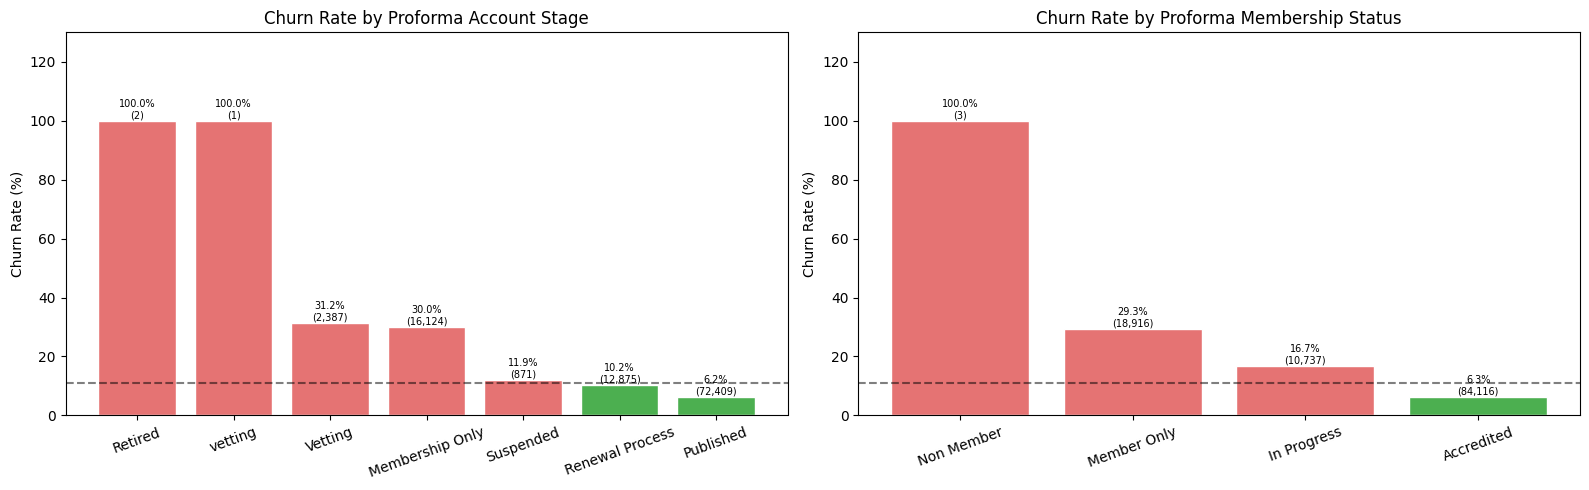

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['Proforma_Account_Stage','Proforma_Membership_Status']):
    stage_churn = (
        sub.groupby(col)['churn']
        .agg(['mean','count'])
        .rename(columns={'mean':'churn_rate','count':'n'})
        .sort_values('churn_rate', ascending=False)
    )
    stage_churn['pct'] = (stage_churn['churn_rate']*100).round(1)
    colors = ['#E57373' if v > overall_churn else '#4CAF50' for v in stage_churn['pct']]
    bars = ax.bar(stage_churn.index, stage_churn['pct'], color=colors, edgecolor='white')
    for bar, val, n in zip(bars, stage_churn['pct'], stage_churn['n']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val}%\n({n:,})', ha='center', va='bottom', fontsize=7)
    ax.axhline(overall_churn, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Churn Rate by {col.replace("_"," ")}')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, stage_churn['pct'].max()*1.3)
plt.tight_layout()
plt.show()

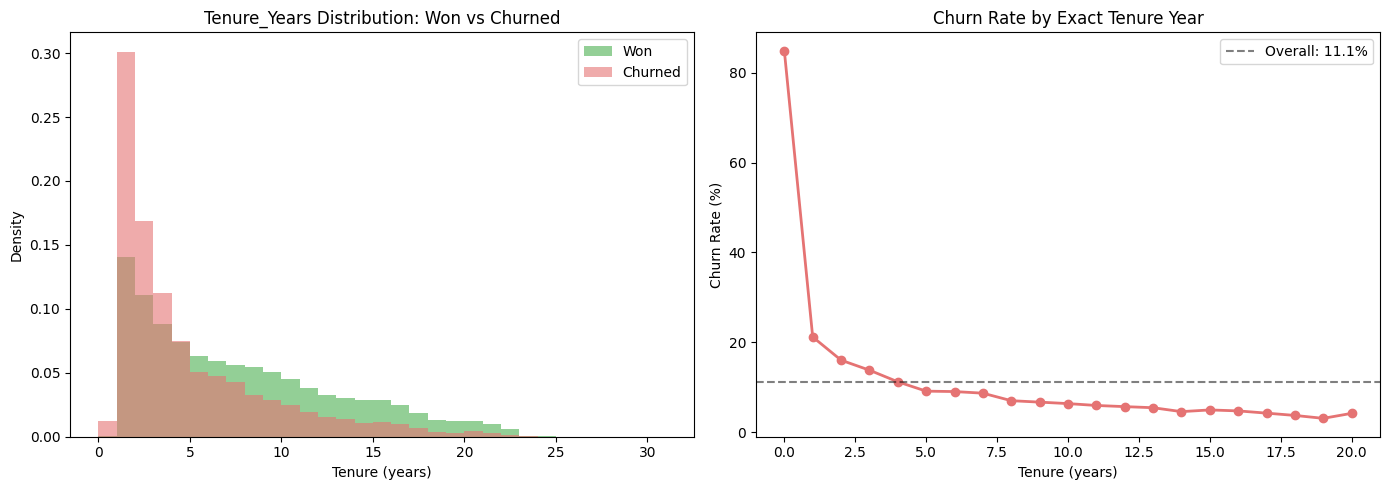

Insight: Clear downward trend — longer tenure = lower churn. Year 1 is the highest risk point.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

won_ten    = sub[sub['churn']==0]['Tenure_Years'].dropna()
churned_ten= sub[sub['churn']==1]['Tenure_Years'].dropna()
axes[0].hist(won_ten,     bins=range(0,32), alpha=0.6, color='#4CAF50',   label='Won',     density=True)
axes[0].hist(churned_ten, bins=range(0,32), alpha=0.6, color='#E57373', label='Churned', density=True)
axes[0].set_title('Tenure_Years Distribution: Won vs Churned')
axes[0].set_xlabel('Tenure (years)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Churn rate by each tenure year
ten_churn = (
    sub[sub['Tenure_Years'] <= 20].groupby('Tenure_Years')['churn']
    .agg(['mean','count'])
)
ten_churn_filtered = ten_churn[ten_churn['count'] >= 100]
axes[1].plot(ten_churn_filtered.index, ten_churn_filtered['mean']*100,
             'o-', color='#E57373', linewidth=2, markersize=6)
axes[1].axhline(overall_churn, color='black', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn:.1f}%')
axes[1].set_title('Churn Rate by Exact Tenure Year')
axes[1].set_xlabel('Tenure (years)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Insight: Clear downward trend — longer tenure = lower churn. Year 1 is the highest risk point.')

## Correlation and Multivariate analysis

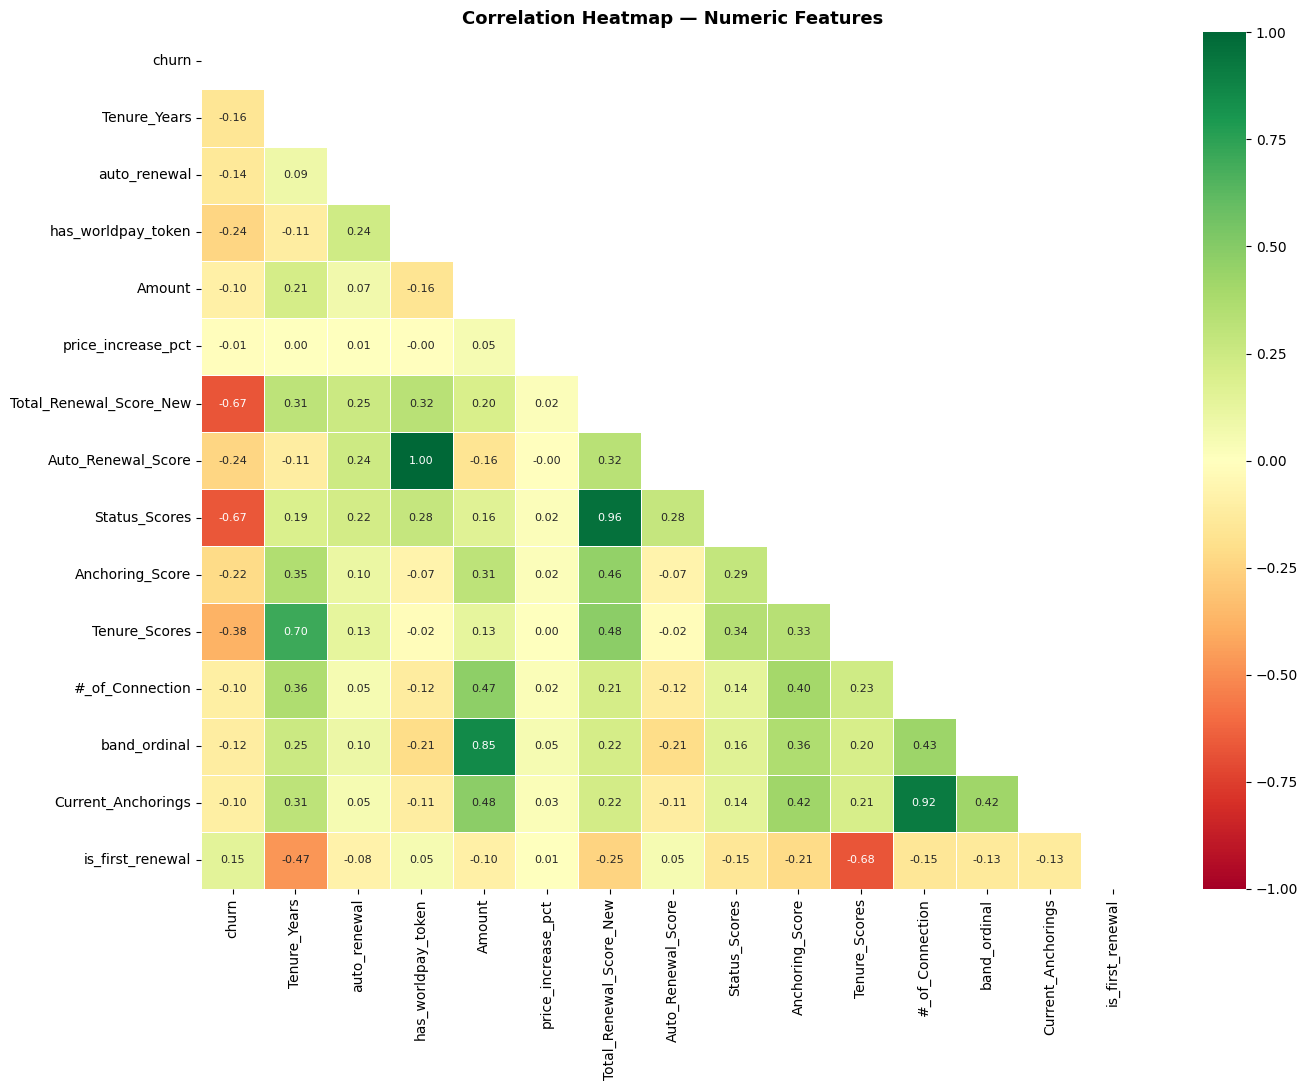


Top correlations with CHURN (sorted by absolute value):
Total_Renewal_Score_New   -0.674
Status_Scores             -0.670
Tenure_Scores             -0.377
Auto_Renewal_Score        -0.241
has_worldpay_token        -0.241
Anchoring_Score           -0.215
Tenure_Years              -0.163
is_first_renewal           0.147
auto_renewal              -0.145
band_ordinal              -0.116
Current_Anchorings        -0.102
#_of_Connection           -0.102
Amount                    -0.101
price_increase_pct        -0.014


In [ ]:
import numpy as np

sub2 = sub.copy()
sub2['auto_renewal']       = (sub2['Current_Auto_Renewal_Flag']=='y').astype(int)
sub2['has_worldpay_token'] = (sub2['Current_World_Pay_Token']=='y').astype(int)
sub2['price_increase_pct'] = (
    (sub2['Amount'] - sub2['Last_Years_Price']) / sub2['Last_Years_Price'] * 100
).round(2)
band_map = {'Band A':1,'Band B':2,'Band C1':3,'Band C2':4,'Band D':5,
            'Band E':6,'Band F':7,'Band F1':8,'Band F2':9,'Band G':10,
            'Band H':11,'Band I':12,'Band J':13,'Group':14}
sub2['band_ordinal'] = sub2['Band'].map(band_map)
sub2['is_first_renewal'] = (sub2['Tenure_Years'] <= 1).astype(int)

num_cols = ['churn','Tenure_Years','auto_renewal','has_worldpay_token',
            'Amount','price_increase_pct','Total_Renewal_Score_New',
            'Auto_Renewal_Score','Status_Scores','Anchoring_Score',
            'Tenure_Scores','#_of_Connection','band_ordinal',
            'Current_Anchorings','is_first_renewal']
num_cols = [c for c in num_cols if c in sub2.columns]
corr = sub2[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop correlations with CHURN (sorted by absolute value):')
print(corr['churn'].drop('churn').sort_values(key=abs, ascending=False).round(3).to_string())

              No Auto-Renewal  Auto-Renewal
Tenure_Group                               
1                        40.1          19.7
2                        35.9          14.2
3                        29.1          12.7
4+                       20.0           6.5


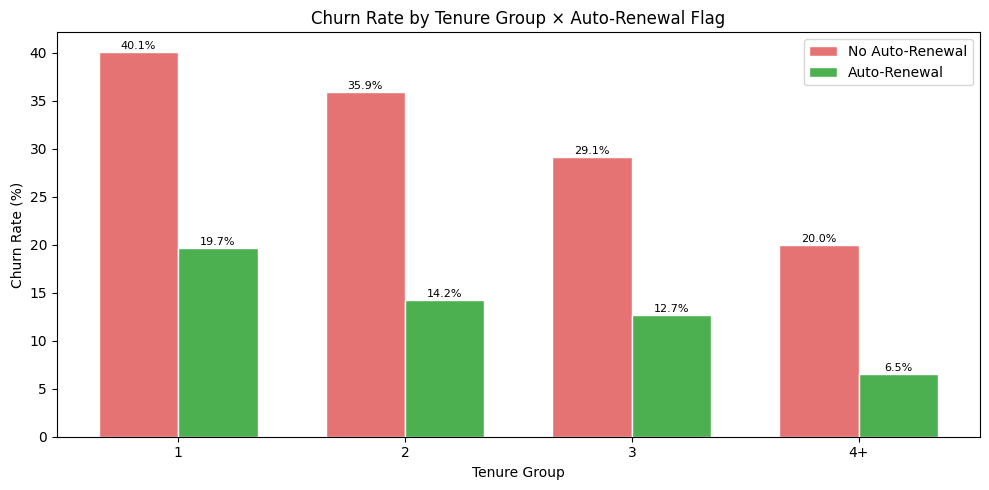

Insight: Highest-risk segment = Year-1 customers WITHOUT auto-renewal.


In [ ]:
mv = (
    sub.groupby(['Tenure_Group','Current_Auto_Renewal_Flag'])['churn']
    .mean().mul(100).round(1).unstack()
)
mv.columns = ['No Auto-Renewal','Auto-Renewal']
mv = mv.reindex([t for t in ['1','2','3','4+'] if t in mv.index])
print(mv)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mv))
w = 0.35
ax.bar(x - w/2, mv['No Auto-Renewal'], w, label='No Auto-Renewal', color='#E57373', edgecolor='white')
ax.bar(x + w/2, mv['Auto-Renewal'],    w, label='Auto-Renewal',    color='#4CAF50',   edgecolor='white')
for i, (no_ar, ar) in enumerate(zip(mv['No Auto-Renewal'], mv['Auto-Renewal'])):
    ax.text(i-w/2, no_ar+0.3, f'{no_ar}%', ha='center', fontsize=8)
    ax.text(i+w/2, ar+0.3,    f'{ar}%',    ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(mv.index)
ax.set_title('Churn Rate by Tenure Group × Auto-Renewal Flag')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()
print('Insight: Highest-risk segment = Year-1 customers WITHOUT auto-renewal.')

         No Auto-Renewal  Auto-Renewal
Band                                  
Band A              30.0          20.6
Band B              34.1          15.6
Band C1             28.2           9.9
Band C2             24.6           7.5
Band D              23.6           6.5
Band E              21.6           5.9


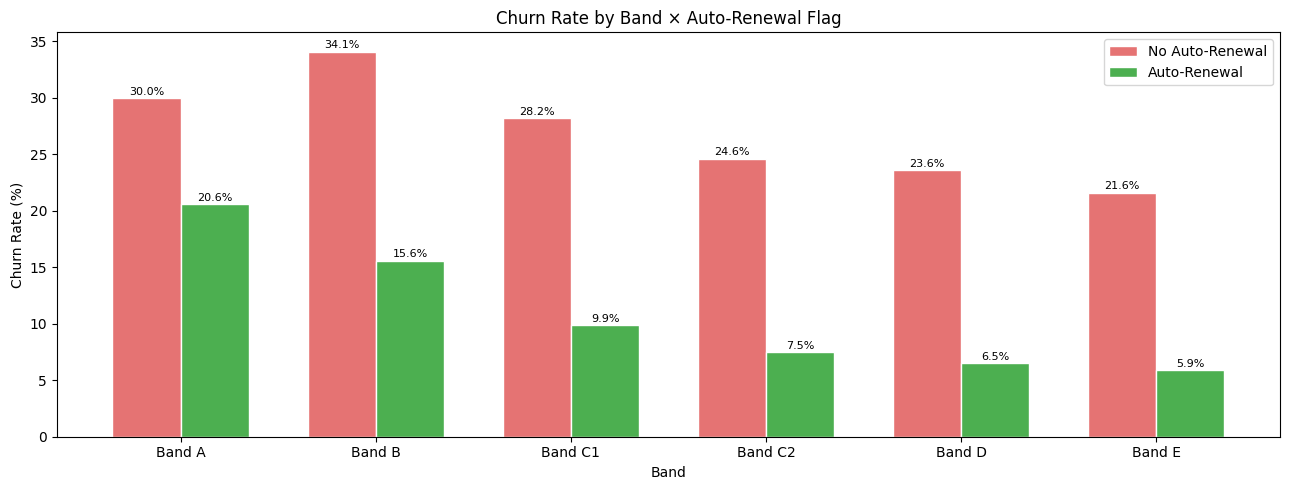

In [ ]:
top_bands = ['Band A','Band B','Band C1','Band C2','Band D','Band E']
mv2 = (
    sub[sub['Band'].isin(top_bands)]
    .groupby(['Band','Current_Auto_Renewal_Flag'])['churn']
    .mean().mul(100).round(1).unstack()
)
mv2.columns = ['No Auto-Renewal','Auto-Renewal']
mv2 = mv2.reindex([b for b in top_bands if b in mv2.index])
print(mv2)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(mv2))
w = 0.35
ax.bar(x-w/2, mv2['No Auto-Renewal'], w, label='No Auto-Renewal', color='#E57373', edgecolor='white')
ax.bar(x+w/2, mv2['Auto-Renewal'],    w, label='Auto-Renewal',    color='#4CAF50',   edgecolor='white')
for i, (no_ar, ar) in enumerate(zip(mv2['No Auto-Renewal'], mv2['Auto-Renewal'])):
    ax.text(i-w/2, no_ar+0.3, f'{no_ar}%', ha='center', fontsize=8)
    ax.text(i+w/2, ar+0.3,    f'{ar}%',    ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(mv2.index)
ax.set_title('Churn Rate by Band × Auto-Renewal Flag')
ax.set_xlabel('Band')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()